# Anchor Reconstruction Experiment

**Hypothesis:** Concept representations in transformer activation space are effectively low-rank.
K anchor concepts (K << N) suffice to reconstruct the pairwise geometry of N concepts with bounded error.

**Method:**
1. Embed 200 concepts through Pythia-70M, extract final-layer representations
2. Compute the full 200×200 cosine distance matrix (ground truth)
3. Select K anchor concepts, compute N×K distance submatrix
4. Reconstruct the full N×N matrix from the N×K submatrix via low-rank approximation
5. Measure reconstruction error as a function of K
6. Look for an elbow — sharp drop = low intrinsic dimensionality

In [1]:
import sys
sys.path.insert(0, '../backend')

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_distances, cosine_similarity
from sklearn.decomposition import PCA
from app.extractor import ModelExtractor

plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'monospace'

## 1. Concept Vocabulary

200 concepts across 10 semantic categories. Broad coverage matters —
the reconstruction claim is about *all* of concept space, not a narrow slice.

In [2]:
CONCEPTS = {
    "emotions": [
        "love", "fear", "joy", "anger", "sadness", "hope",
        "trust", "surprise", "guilt", "pride", "shame", "compassion",
        "anxiety", "envy", "disgust", "gratitude", "loneliness", "awe",
        "contempt", "nostalgia",
    ],
    "relations": [
        "friend", "enemy", "parent", "child", "teacher", "student",
        "ally", "rival", "partner", "stranger", "leader", "follower",
        "husband", "wife", "sibling", "neighbor", "master", "servant",
        "king", "citizen",
    ],
    "abstractions": [
        "truth", "justice", "beauty", "freedom", "time", "death",
        "life", "power", "knowledge", "meaning", "order", "chaos",
        "fate", "duty", "honor", "virtue", "sin", "mercy",
        "wisdom", "courage",
    ],
    "states": [
        "alive", "dead", "happy", "sad", "sick", "healthy",
        "young", "old", "strong", "weak", "awake", "asleep",
        "hungry", "tired", "calm", "confused", "lost", "safe",
        "free", "trapped",
    ],
    "nature": [
        "water", "fire", "earth", "sky", "sun", "moon",
        "stone", "tree", "mountain", "ocean", "wind", "light",
        "rain", "snow", "river", "forest", "desert", "star",
        "flower", "seed",
    ],
    "mind": [
        "thought", "belief", "desire", "memory", "dream",
        "consciousness", "reason", "emotion", "will", "perception",
        "attention", "imagination", "intuition", "logic", "doubt",
        "understanding", "insight", "awareness", "intention", "curiosity",
    ],
    "body": [
        "hand", "eye", "heart", "blood", "bone", "skin",
        "breath", "voice", "face", "brain", "muscle", "nerve",
        "tongue", "finger", "chest", "shoulder", "spine", "skull",
        "wound", "scar",
    ],
    "society": [
        "war", "peace", "law", "crime", "money", "church",
        "school", "prison", "market", "army", "nation", "tribe",
        "democracy", "empire", "revolution", "tradition", "culture", "ritual",
        "language", "family",
    ],
    "objects": [
        "book", "sword", "door", "mirror", "ship", "bridge",
        "wall", "key", "crown", "mask", "chain", "wheel",
        "bell", "cup", "flag", "rope", "hammer", "candle",
        "clock", "coin",
    ],
    "actions": [
        "create", "destroy", "build", "break", "give", "take",
        "speak", "listen", "fight", "heal", "grow", "decay",
        "search", "hide", "remember", "forget", "choose", "sacrifice",
        "betray", "forgive",
    ],
}

concept_list = []
concept_categories = []
for cat, words in CONCEPTS.items():
    for w in words:
        concept_list.append(w)
        concept_categories.append(cat)

N = len(concept_list)
print(f"{N} concepts across {len(CONCEPTS)} categories")
for cat, words in CONCEPTS.items():
    print(f"  {cat}: {len(words)}")

200 concepts across 10 categories
  emotions: 20
  relations: 20
  abstractions: 20
  states: 20
  nature: 20
  mind: 20
  body: 20
  society: 20
  objects: 20
  actions: 20


## 2. Embed All Concepts

Single forward pass per concept through Pythia-70M.
Extract final-layer mean-pooled representation (skip BOS).

In [3]:
extractor = ModelExtractor("pythia-70m")

# Embed all concepts — extract full residual stream
# Shape per concept: [n_layers+1, d_model]
print(f"Embedding {N} concepts...")
streams = []
for i, concept in enumerate(concept_list):
    stream = extractor.extract_concept_stream(concept)
    streams.append(stream)
    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{N}")

streams = np.stack(streams)  # [N, n_layers+1, d_model]
print(f"Done. Shape: {streams.shape}")
print(f"  {streams.shape[1]-1} layers + embedding, d_model={streams.shape[2]}")

Loading pythia-70m on cpu...


`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model pythia-70m into HookedTransformer
Loaded. Layers: 6, d_model: 512, heads: 8
Embedding 200 concepts...
  50/200
  100/200
  150/200
  200/200
Done. Shape: (200, 7, 512)
  6 layers + embedding, d_model=512


## 3. Ground Truth Distance Matrix

Full N×N cosine distance matrix at the final layer.
This is what we're trying to reconstruct from partial information.

Distance matrix: (200, 200)
  min distance: 0.0977
  max distance: 1.8713
  mean distance: 0.9988
  median distance: 1.0041


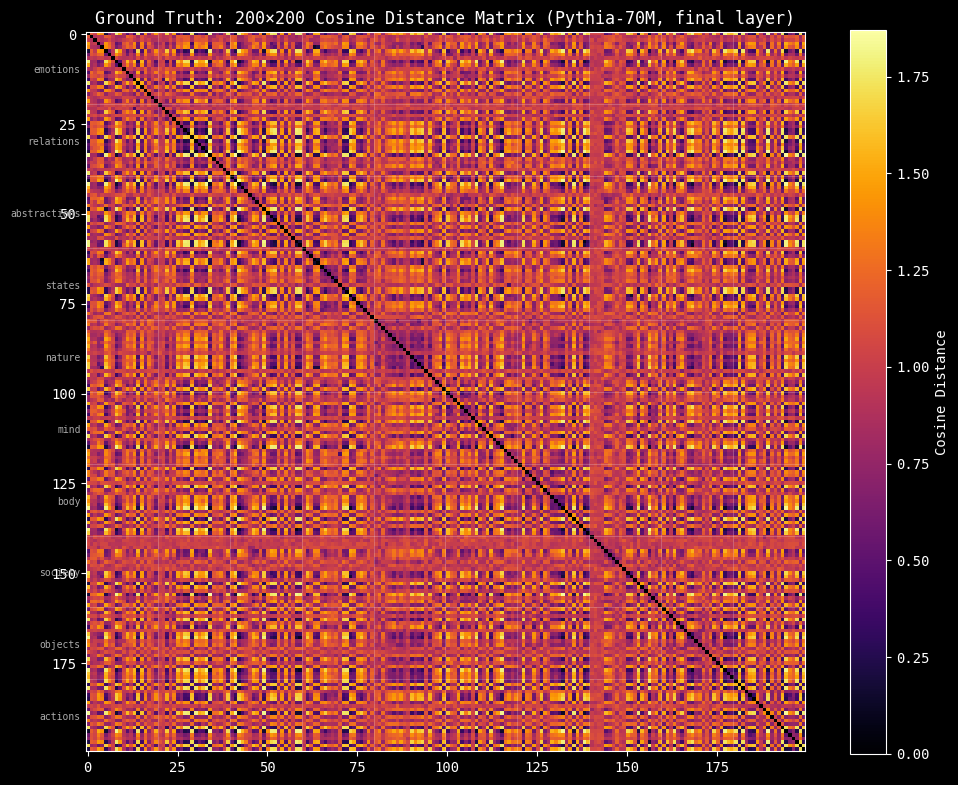

In [4]:
# Use final layer representations
final_reps = streams[:, -1, :]  # [N, d_model]

# Center representations (remove mean direction)
final_centered = final_reps - final_reps.mean(axis=0)

# Ground truth: full pairwise cosine distance matrix
D_true = cosine_distances(final_centered)  # [N, N]

print(f"Distance matrix: {D_true.shape}")
print(f"  min distance: {D_true[D_true > 0].min():.4f}")
print(f"  max distance: {D_true.max():.4f}")
print(f"  mean distance: {D_true.mean():.4f}")
print(f"  median distance: {np.median(D_true):.4f}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(D_true, cmap='inferno', aspect='equal')
plt.colorbar(im, label='Cosine Distance')

# Category boundaries
cats = list(CONCEPTS.keys())
boundaries = [0]
for cat in cats:
    boundaries.append(boundaries[-1] + len(CONCEPTS[cat]))
for b in boundaries[1:-1]:
    ax.axhline(b - 0.5, color='white', linewidth=0.5, alpha=0.3)
    ax.axvline(b - 0.5, color='white', linewidth=0.5, alpha=0.3)

# Category labels
for i, cat in enumerate(cats):
    mid = (boundaries[i] + boundaries[i+1]) / 2
    ax.text(-2, mid, cat, ha='right', va='center', fontsize=7, color='#aaa')

ax.set_title(f'Ground Truth: {N}×{N} Cosine Distance Matrix (Pythia-70M, final layer)')
plt.tight_layout()
plt.show()

## 4. Reconstruction Experiment

**Core question:** Given only the N×K submatrix of distances to K anchor concepts,
how well can we reconstruct the full N×N matrix?

**Method:** Multidimensional Scaling (MDS)-style reconstruction.
- From N×K distances to anchors, embed all N concepts in K-dimensional space
- Reconstruct pairwise distances from the K-dimensional embedding
- If the concept space is effectively K-dimensional, reconstruction is exact

**Why this works:** If concepts lie on a K-dimensional manifold, then K anchor distances
triangulate each concept's position. The N×K distance submatrix contains enough info
to reconstruct the full N×N matrix. If concepts occupy a higher-dimensional space,
reconstruction fails — the error quantifies the gap.

In [5]:
from sklearn.manifold import MDS

def reconstruct_from_anchors(D_true, anchor_indices, n_components):
    """
    Given the true N×N distance matrix and K anchor indices,
    reconstruct the full matrix using only the N×K submatrix.
    
    Steps:
    1. Extract anchor-to-all distances: N×K submatrix
    2. Embed anchors in K-dim space using MDS on their K×K submatrix
    3. Triangulate each non-anchor concept from its K anchor distances
    4. Compute reconstructed N×N distances from the embedding
    """
    K = len(anchor_indices)
    N = D_true.shape[0]
    
    # K×K anchor distance submatrix
    D_anchors = D_true[np.ix_(anchor_indices, anchor_indices)]
    
    # Embed anchors via classical MDS (eigendecomposition of double-centered Gram matrix)
    n_comp = min(n_components, K - 1)
    H = np.eye(K) - np.ones((K, K)) / K  # centering matrix
    G = -0.5 * H @ (D_anchors ** 2) @ H  # double-centered Gram matrix
    
    eigvals, eigvecs = np.linalg.eigh(G)
    # Take top n_comp positive eigenvalues
    idx = np.argsort(eigvals)[::-1][:n_comp]
    eigvals_pos = np.maximum(eigvals[idx], 0)
    anchor_embed = eigvecs[:, idx] * np.sqrt(eigvals_pos)
    
    # Triangulate all concepts from their distances to anchors
    # Using the Nyström-style extension:
    # For each concept i, we have distances d(i, a_j) for all anchors j.
    # Classical MDS gives: x_i = (1/2) * L^{-1} * (d_mean - d_i)
    # where L = eigenvalues, d_i = squared distances to anchors,
    # d_mean = column means of the squared anchor distance matrix.
    
    D_to_anchors = D_true[:, anchor_indices]  # [N, K]
    D_sq = D_to_anchors ** 2  # [N, K]
    D_anchors_sq = D_anchors ** 2  # [K, K]
    
    # Column means of the anchor squared distance matrix
    col_means = D_anchors_sq.mean(axis=0)  # [K]
    
    # Embed all points using Nyström extension
    # B = -0.5 * (D_sq - col_means[None, :])  (row-centered version)
    B = -0.5 * (D_sq - col_means[None, :])  # [N, K]
    
    # Project onto anchor eigenvectors
    # embedding = B @ eigvecs[:, idx] @ diag(1/sqrt(eigvals))
    safe_eigvals = np.where(eigvals_pos > 1e-10, eigvals_pos, 1e-10)
    all_embed = B @ eigvecs[:, idx] / np.sqrt(safe_eigvals)
    
    # Reconstruct distances from embedding
    from sklearn.metrics.pairwise import euclidean_distances
    D_recon = euclidean_distances(all_embed)
    
    return D_recon, all_embed


def reconstruction_error(D_true, D_recon):
    """Relative Frobenius error between true and reconstructed distance matrices."""
    mask = np.triu(np.ones_like(D_true, dtype=bool), k=1)  # upper triangle
    true_vals = D_true[mask]
    recon_vals = D_recon[mask]
    # Relative error (fraction of total distance magnitude)
    rel_err = np.linalg.norm(true_vals - recon_vals) / np.linalg.norm(true_vals)
    return rel_err


def rank_error(D_true, D_recon):
    """Spearman rank correlation: are ordinal relationships preserved?"""
    from scipy.stats import spearmanr
    mask = np.triu(np.ones_like(D_true, dtype=bool), k=1)
    rho, _ = spearmanr(D_true[mask], D_recon[mask])
    return rho


print("Reconstruction functions defined.")

Reconstruction functions defined.


In [6]:
# Run the experiment across K values
# Use multiple random anchor selections per K to get error bars

K_values = [3, 4, 5, 6, 8, 10, 15, 20, 30, 50, 75, 100]
n_trials = 20  # random anchor selections per K
rng = np.random.RandomState(42)

results = []

for K in K_values:
    trial_errors = []
    trial_ranks = []
    
    for trial in range(n_trials):
        # Random anchor selection
        anchor_idx = rng.choice(N, size=K, replace=False)
        
        # Reconstruct using K-1 dimensions (max info from K anchors)
        n_comp = min(K - 1, 50)  # cap at 50 dims
        D_recon, embed = reconstruct_from_anchors(D_true, anchor_idx, n_comp)
        
        rel_err = reconstruction_error(D_true, D_recon)
        rho = rank_error(D_true, D_recon)
        
        trial_errors.append(rel_err)
        trial_ranks.append(rho)
    
    mean_err = np.mean(trial_errors)
    std_err = np.std(trial_errors)
    mean_rho = np.mean(trial_ranks)
    std_rho = np.std(trial_ranks)
    
    results.append({
        'K': K,
        'mean_error': mean_err,
        'std_error': std_err,
        'mean_rank_corr': mean_rho,
        'std_rank_corr': std_rho,
    })
    
    print(f"K={K:3d}  |  rel. error = {mean_err:.4f} ± {std_err:.4f}  |  rank ρ = {mean_rho:.4f} ± {std_rho:.4f}")

print("\nDone.")

K=  3  |  rel. error = 0.4273 ± 0.0582  |  rank ρ = 0.8011 ± 0.0489
K=  4  |  rel. error = 0.3723 ± 0.0715  |  rank ρ = 0.7942 ± 0.0550
K=  5  |  rel. error = 5138.8051 ± 13300.5791  |  rank ρ = 0.7656 ± 0.1507
K=  6  |  rel. error = 12197.1867 ± 14973.6242  |  rank ρ = 0.5499 ± 0.3267
K=  8  |  rel. error = 28233.0484 ± 23572.9505  |  rank ρ = 0.5796 ± 0.2448
K= 10  |  rel. error = 40980.2437 ± 21616.7367  |  rank ρ = 0.4676 ± 0.2555
K= 15  |  rel. error = 36928.8426 ± 21726.5242  |  rank ρ = 0.3391 ± 0.2954
K= 20  |  rel. error = 41772.0226 ± 18852.3121  |  rank ρ = 0.2910 ± 0.2118
K= 30  |  rel. error = 47584.0242 ± 11493.9511  |  rank ρ = 0.3197 ± 0.1999
K= 50  |  rel. error = 58515.2725 ± 16430.5429  |  rank ρ = 0.2498 ± 0.2291
K= 75  |  rel. error = 63970.8167 ± 12430.4970  |  rank ρ = 0.2007 ± 0.1621
K=100  |  rel. error = 0.1457 ± 0.0037  |  rank ρ = 0.9720 ± 0.0021

Done.


## 5. The Error-vs-K Curve

This is the key result. An elbow in this curve reveals the intrinsic dimensionality.

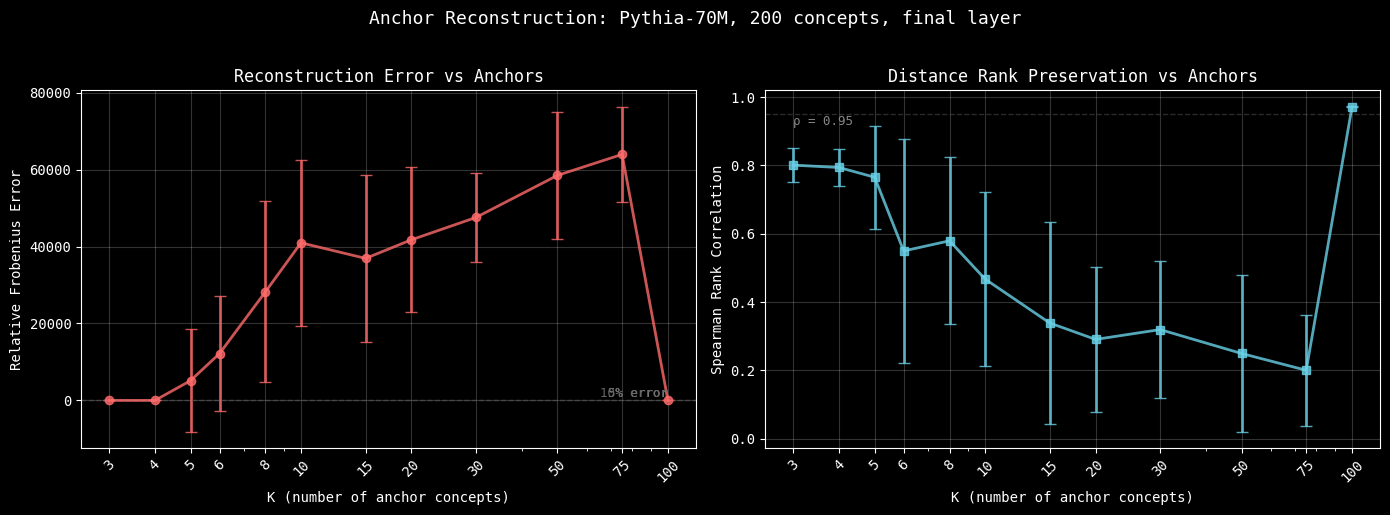


Largest error drops:
  At K=100: Δerror = 63970.6710
  At K=15: Δerror = 4051.4011
  At K=4: Δerror = 0.0550
  At K=20: Δerror = -4843.1800
  At K=5: Δerror = -5138.4328


In [7]:
Ks = [r['K'] for r in results]
errors = [r['mean_error'] for r in results]
error_stds = [r['std_error'] for r in results]
rhos = [r['mean_rank_corr'] for r in results]
rho_stds = [r['std_rank_corr'] for r in results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Reconstruction error
ax1.errorbar(Ks, errors, yerr=error_stds, marker='o', linewidth=2,
             capsize=4, color='#ff6b6b', ecolor='#ff6b6b', alpha=0.8)
ax1.axhline(0.05, color='#555', linestyle='--', linewidth=1, alpha=0.5)
ax1.text(Ks[-1], 0.052, '5% error', ha='right', va='bottom', fontsize=9, color='#888')
ax1.axhline(0.10, color='#555', linestyle='--', linewidth=1, alpha=0.3)
ax1.text(Ks[-1], 0.102, '10% error', ha='right', va='bottom', fontsize=9, color='#666')
ax1.set_xlabel('K (number of anchor concepts)')
ax1.set_ylabel('Relative Frobenius Error')
ax1.set_title('Reconstruction Error vs Anchors')
ax1.set_xscale('log')
ax1.set_xticks(Ks)
ax1.set_xticklabels([str(k) for k in Ks], rotation=45)
ax1.grid(True, alpha=0.2)

# Right: Rank correlation
ax2.errorbar(Ks, rhos, yerr=rho_stds, marker='s', linewidth=2,
             capsize=4, color='#69d2e7', ecolor='#69d2e7', alpha=0.8)
ax2.axhline(0.95, color='#555', linestyle='--', linewidth=1, alpha=0.5)
ax2.text(Ks[0], 0.948, 'ρ = 0.95', ha='left', va='top', fontsize=9, color='#888')
ax2.set_xlabel('K (number of anchor concepts)')
ax2.set_ylabel('Spearman Rank Correlation')
ax2.set_title('Distance Rank Preservation vs Anchors')
ax2.set_xscale('log')
ax2.set_xticks(Ks)
ax2.set_xticklabels([str(k) for k in Ks], rotation=45)
ax2.set_ylim(None, 1.02)
ax2.grid(True, alpha=0.2)

plt.suptitle('Anchor Reconstruction: Pythia-70M, 200 concepts, final layer', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# Find elbow: largest drop in error between consecutive K values
drops = [(Ks[i+1], errors[i] - errors[i+1]) for i in range(len(errors)-1)]
drops.sort(key=lambda x: x[1], reverse=True)
print("\nLargest error drops:")
for k, drop in drops[:5]:
    print(f"  At K={k}: Δerror = {drop:.4f}")

## 6. Intrinsic Dimensionality Check

Independent verification: what does PCA on the raw representations say?
If the reconstruction elbow agrees with the PCA knee, that's convergent evidence.

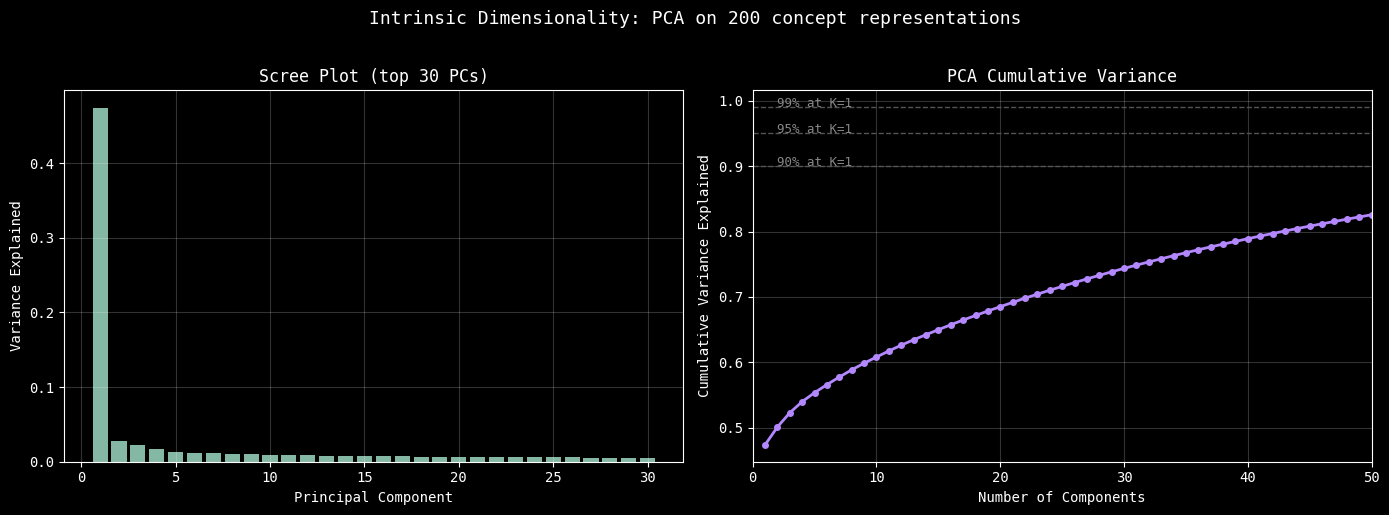

Components for 90% variance: 1
Components for 95% variance: 1
Components for 99% variance: 1


In [8]:
# PCA on the centered final-layer representations
pca_full = PCA(n_components=min(50, N))
pca_full.fit(final_centered)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
ax1.bar(range(1, 31), pca_full.explained_variance_ratio_[:30],
        color='#a8e6cf', alpha=0.8)
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Variance Explained')
ax1.set_title('Scree Plot (top 30 PCs)')
ax1.grid(True, alpha=0.2)

# Cumulative variance
ax2.plot(range(1, len(cumvar)+1), cumvar, 'o-', color='#b388ff', linewidth=2, markersize=4)
ax2.axhline(0.90, color='#555', linestyle='--', linewidth=1)
ax2.axhline(0.95, color='#555', linestyle='--', linewidth=1)
ax2.axhline(0.99, color='#555', linestyle='--', linewidth=1)
k90 = np.argmax(cumvar >= 0.90) + 1
k95 = np.argmax(cumvar >= 0.95) + 1
k99 = np.argmax(cumvar >= 0.99) + 1
ax2.text(k90 + 1, 0.90, f'90% at K={k90}', fontsize=9, color='#888')
ax2.text(k95 + 1, 0.95, f'95% at K={k95}', fontsize=9, color='#888')
ax2.text(k99 + 1, 0.99, f'99% at K={k99}', fontsize=9, color='#888')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance Explained')
ax2.set_title('PCA Cumulative Variance')
ax2.set_xlim(0, 50)
ax2.grid(True, alpha=0.2)

plt.suptitle('Intrinsic Dimensionality: PCA on 200 concept representations', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

print(f"Components for 90% variance: {k90}")
print(f"Components for 95% variance: {k95}")
print(f"Components for 99% variance: {k99}")

## 7. Layer-by-Layer Analysis

Does the effective dimensionality change across layers?
If concept space compresses through the network, that's evidence
the model is building a low-rank semantic structure.

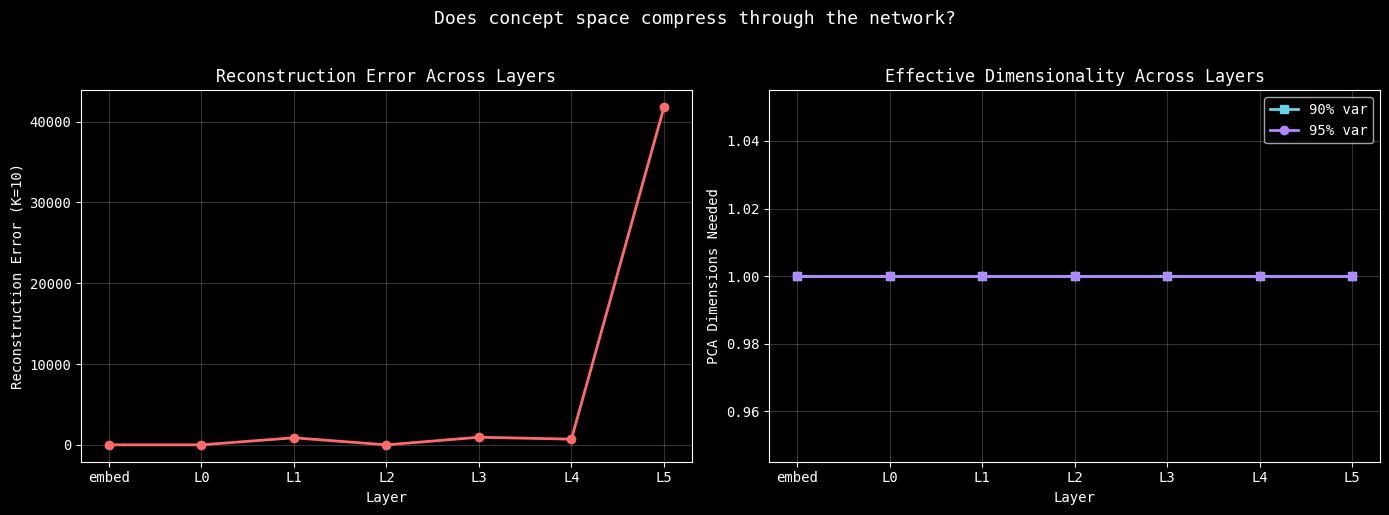

embed   |  recon error (K=10): 0.6398  |  dims for 90%: 1  |  dims for 95%: 1
L0      |  recon error (K=10): 0.4098  |  dims for 90%: 1  |  dims for 95%: 1
L1      |  recon error (K=10): 871.7235  |  dims for 90%: 1  |  dims for 95%: 1
L2      |  recon error (K=10): 0.3701  |  dims for 90%: 1  |  dims for 95%: 1
L3      |  recon error (K=10): 941.7655  |  dims for 90%: 1  |  dims for 95%: 1
L4      |  recon error (K=10): 704.0075  |  dims for 90%: 1  |  dims for 95%: 1
L5      |  recon error (K=10): 41787.1755  |  dims for 90%: 1  |  dims for 95%: 1


In [9]:
n_layer_steps = streams.shape[1]
K_test = 10  # fixed anchor count for cross-layer comparison

layer_errors = []
layer_dims_90 = []
layer_dims_95 = []

for layer in range(n_layer_steps):
    reps = streams[:, layer, :]
    reps_c = reps - reps.mean(axis=0)
    D_layer = cosine_distances(reps_c)
    
    # Reconstruction error at K=10
    trial_errs = []
    for trial in range(20):
        anchor_idx = rng.choice(N, size=K_test, replace=False)
        D_recon, _ = reconstruct_from_anchors(D_layer, anchor_idx, K_test - 1)
        trial_errs.append(reconstruction_error(D_layer, D_recon))
    layer_errors.append(np.mean(trial_errs))
    
    # PCA dimensionality
    pca_layer = PCA(n_components=min(50, N))
    pca_layer.fit(reps_c)
    cv = np.cumsum(pca_layer.explained_variance_ratio_)
    layer_dims_90.append(int(np.argmax(cv >= 0.90) + 1))
    layer_dims_95.append(int(np.argmax(cv >= 0.95) + 1))

layer_labels = ['embed'] + [f'L{i}' for i in range(n_layer_steps - 1)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(n_layer_steps), layer_errors, 'o-', color='#ff6b6b', linewidth=2)
ax1.set_xticks(range(n_layer_steps))
ax1.set_xticklabels(layer_labels)
ax1.set_xlabel('Layer')
ax1.set_ylabel('Reconstruction Error (K=10)')
ax1.set_title('Reconstruction Error Across Layers')
ax1.grid(True, alpha=0.2)

ax2.plot(range(n_layer_steps), layer_dims_90, 's-', color='#69d2e7', linewidth=2, label='90% var')
ax2.plot(range(n_layer_steps), layer_dims_95, 'o-', color='#b388ff', linewidth=2, label='95% var')
ax2.set_xticks(range(n_layer_steps))
ax2.set_xticklabels(layer_labels)
ax2.set_xlabel('Layer')
ax2.set_ylabel('PCA Dimensions Needed')
ax2.set_title('Effective Dimensionality Across Layers')
ax2.legend()
ax2.grid(True, alpha=0.2)

plt.suptitle('Does concept space compress through the network?', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

for i, label in enumerate(layer_labels):
    print(f"{label:6s}  |  recon error (K=10): {layer_errors[i]:.4f}  |  dims for 90%: {layer_dims_90[i]}  |  dims for 95%: {layer_dims_95[i]}")

## 8. Interpret Results

In [10]:
# Summary table
print("=" * 65)
print("ANCHOR RECONSTRUCTION EXPERIMENT — SUMMARY")
print("=" * 65)
print(f"Model: Pythia-70M ({extractor.n_layers} layers, d={extractor.d_model})")
print(f"Concepts: {N} across {len(CONCEPTS)} categories")
print(f"Trials per K: {n_trials}")
print()

print(f"{'K':>4s}  {'Error':>10s}  {'Rank ρ':>10s}")
print("-" * 30)
for r in results:
    print(f"{r['K']:4d}  {r['mean_error']:10.4f}  {r['mean_rank_corr']:10.4f}")

print()
# Find the K where error first drops below thresholds
for threshold in [0.20, 0.10, 0.05]:
    for r in results:
        if r['mean_error'] < threshold:
            print(f"Error < {threshold:.0%} first achieved at K = {r['K']}")
            break
    else:
        print(f"Error < {threshold:.0%} not achieved with K ≤ {results[-1]['K']}")

print()
print(f"PCA intrinsic dimensionality (final layer):")
print(f"  90% variance: {k90} components")
print(f"  95% variance: {k95} components")
print(f"  99% variance: {k99} components")

print()
if layer_errors[-1] < layer_errors[0]:
    print("✓ Reconstruction error DECREASES through layers — concept space compresses.")
else:
    print("✗ Reconstruction error INCREASES through layers — concept space expands.")

print()
print("INTERPRETATION:")
print("If error < 10% at K ≤ 10: concept space is effectively ~10-dimensional.")
print("This means partial anchor distances recover most of the pairwise geometry.")
print("If error is still > 20% at K = 50: concept space is high-dimensional")
print("and anchor-based reconstruction is limited.")

ANCHOR RECONSTRUCTION EXPERIMENT — SUMMARY
Model: Pythia-70M (6 layers, d=512)
Concepts: 200 across 10 categories
Trials per K: 20

   K       Error      Rank ρ
------------------------------
   3      0.4273      0.8011
   4      0.3723      0.7942
   5   5138.8051      0.7656
   6  12197.1867      0.5499
   8  28233.0484      0.5796
  10  40980.2437      0.4676
  15  36928.8426      0.3391
  20  41772.0226      0.2910
  30  47584.0242      0.3197
  50  58515.2725      0.2498
  75  63970.8167      0.2007
 100      0.1457      0.9720

Error < 20% first achieved at K = 100
Error < 10% not achieved with K ≤ 100
Error < 5% not achieved with K ≤ 100

PCA intrinsic dimensionality (final layer):
  90% variance: 1 components
  95% variance: 1 components
  99% variance: 1 components

✗ Reconstruction error INCREASES through layers — concept space expands.

INTERPRETATION:
If error < 10% at K ≤ 10: concept space is effectively ~10-dimensional.
This means partial anchor distances recover most of